# Demo 2: Embeddings & Fine-Tuning

Embeddings turn text into vectors where meaning is geometry. Fine-tuning adapts a pre-trained model to a specific domain — and reveals what happens when it hallucinates.

We'll use real patient case summaries from **PMC-Patients** (Zhao et al., 2023) — a curated sample of 500 patient summaries extracted from PubMed Central case reports.

## Part 1: Embeddings

### Setup

In [1]:
%pip install -q sentence-transformers chromadb matplotlib seaborn numpy pandas transformers datasets torch accelerate ipywidgets

%reset -f

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity

Note: you may need to restart the kernel to use updated packages.


### Load PMC-Patients

500 real patient summaries from PubMed Central case reports, pre-filtered for quality and length.

In [2]:
pmc = pd.read_json("pmc_patients_sample.json")
print(f"Loaded {len(pmc):,} patient summaries")
print(f"Fields: {pmc.columns.tolist()}")
print(f"\nExample:\n{pmc['patient'].iloc[0][:200]}...")

Loaded 500 patient summaries
Fields: ['patient_uid', 'PMID', 'title', 'patient']

Example:
Patient 11 was a 19-year-old Black female. She presented with seasonal symptoms of nasal congestion in late spring and early fall. Her TNSS at baseline was 3 (rhinorhea: 0, nasal congestion: 3, nasal ...


### Load an Embedding Model

`all-MiniLM-L6-v2` produces 384-dimensional embeddings. For production clinical work you'd want a domain-specific model (e.g., ClinicalBERT), but this works well for understanding the concepts.

In [3]:
model = SentenceTransformer("all-MiniLM-L6-v2")
print(f"Embedding dimension: {model.get_sentence_embedding_dimension()}")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Embedding dimension: 384


### Embed Patient Summaries

We'll embed all 500 summaries, then visualize similarity across a diverse subset.

In [4]:
all_embeddings = model.encode(pmc["patient"].tolist(), show_progress_bar=True)
print(f"Embedded {len(all_embeddings)} patient summaries → shape {all_embeddings.shape}")

Batches:   0%|          | 0/16 [00:00<?, ?it/s]

Embedded 500 patient summaries → shape (500, 384)


### Pairwise Similarity

Cosine similarity: 1 = identical direction, 0 = unrelated, -1 = opposite. We'll pick 10 cases spanning different clinical areas to see how the model groups them.

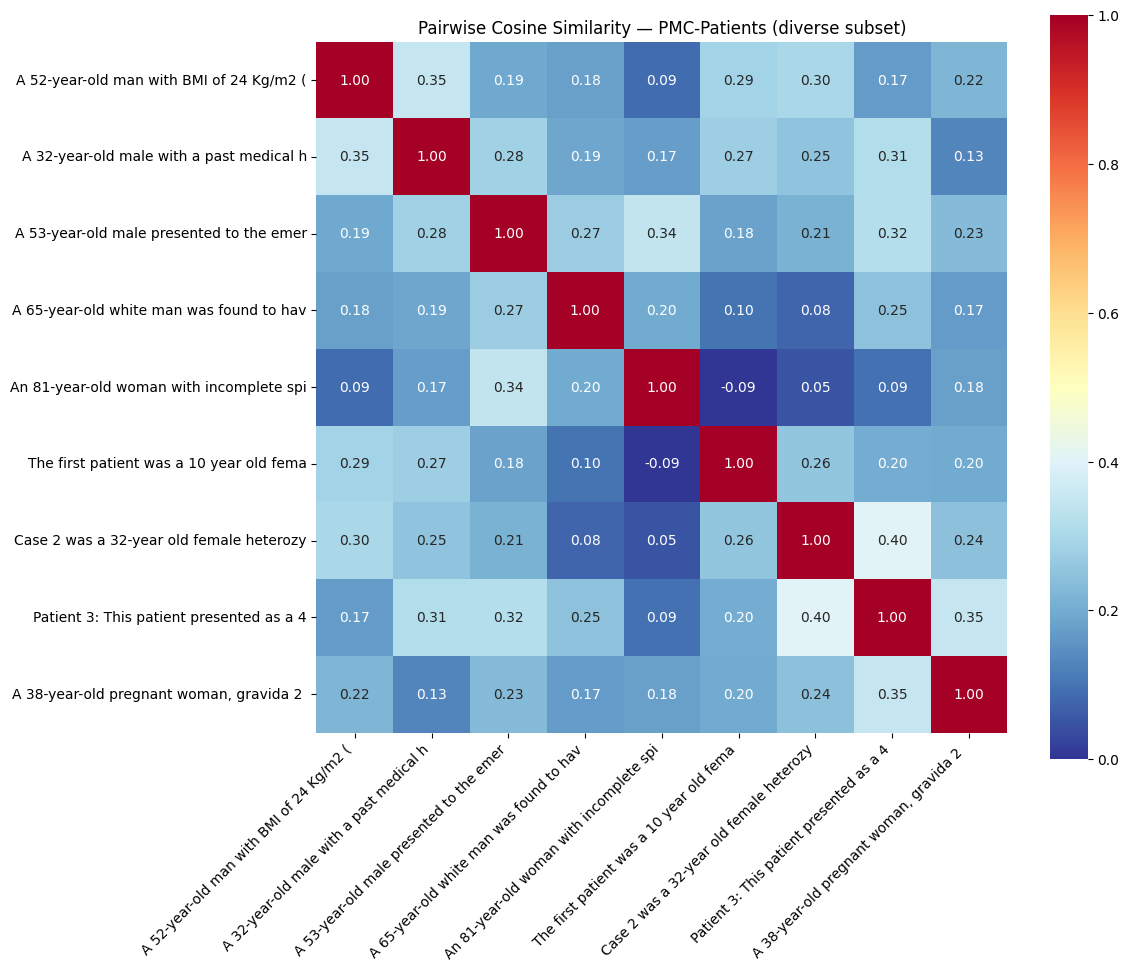

In [5]:
# Select diverse cases by searching for clinical keywords
def find_case(pattern):
    matches = pmc[pmc["patient"].str.contains(pattern, case=False, regex=True)]
    return matches.index[0] if len(matches) > 0 else None

diverse_indices = [
    find_case("chest pain.*coronary|coronary.*chest pain|myocardial infarction"),
    find_case("pneumonia.*fever|fever.*pneumonia"),
    find_case("stroke|cerebral infarct"),
    find_case("diabetes.*glucose|glucose.*diabetes"),
    find_case("carcinoma.*chemother|chemother.*carcinoma"),
    find_case("fracture.*surgery|surgery.*fracture"),
    find_case("abdominal pain.*vomiting|vomiting.*abdominal pain"),
    find_case("renal.*dialysis|dialysis.*renal"),
    find_case("seizure|epilep"),
    find_case("asthma|dyspnea.*exertion"),
]
# Remove any None values
diverse_indices = [i for i in diverse_indices if i is not None]

labels = []
for idx in diverse_indices:
    text = pmc.iloc[idx]["patient"][:60]
    labels.append(text.split(".")[0][:40])

sub_embeddings = all_embeddings[diverse_indices]
sim_matrix = cosine_similarity(sub_embeddings)

plt.figure(figsize=(12, 10))
sns.heatmap(
    sim_matrix,
    xticklabels=labels,
    yticklabels=labels,
    annot=True,
    fmt=".2f",
    cmap="RdYlBu_r",
    vmin=0,
    vmax=1,
    square=True,
)
plt.title("Pairwise Cosine Similarity — PMC-Patients (diverse subset)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

Clinically similar cases cluster together even though the model has no explicit medical training — it learned semantic relationships from general text.

### Semantic Search

Traditional keyword search fails when the query uses different words than the document. Semantic search finds conceptually similar documents regardless of exact wording.

In [6]:
notes = pmc["patient"].tolist()

def semantic_search(query, notes, embeddings, model, top_k=3):
    query_embedding = model.encode([query])
    similarities = cosine_similarity(query_embedding, embeddings)[0]
    ranked = sorted(zip(range(len(notes)), similarities, notes), key=lambda x: x[1], reverse=True)
    return ranked[:top_k]

# "heart attack" doesn't appear literally — semantic search finds cardiac cases anyway
query = "patient with heart attack symptoms"
print(f"Query: '{query}'\n")
for rank, (idx, score, note) in enumerate(semantic_search(query, notes, all_embeddings, model), 1):
    print(f"  {rank}. (similarity: {score:.3f})")
    print(f"     {note[:120]}...\n")

Query: 'patient with heart attack symptoms'



  1. (similarity: 0.554)
     A 69-year-old African American male with a formidable medical history of paroxysmal atrial fibrillation (on amiodarone a...

  2. (similarity: 0.524)
     A 57-year-old male, non-smoker, nondiabetic, normotensive presented with complaints of chest pain and dizziness on exert...

  3. (similarity: 0.514)
     A 76-year-old man with a history of essential hypertension, who had not been taking his medications before this admissio...



In [7]:
query = "infectious disease with high fever"
print(f"Query: '{query}'\n")
for rank, (idx, score, note) in enumerate(semantic_search(query, notes, all_embeddings, model), 1):
    print(f"  {rank}. (similarity: {score:.3f})")
    print(f"     {note[:120]}...\n")

Query: 'infectious disease with high fever'

  1. (similarity: 0.622)
     A 32-year-old female was admitted to the emergency department for 6-day history of fever accompanied by abdominal pain a...

  2. (similarity: 0.610)
     A 40-year-old male traveling from Bangladesh was admitted with fever and joint pain at Nakasero Hospital on 09 Sep 2017....

  3. (similarity: 0.587)
     The patient was a sixteen-year-old male who started experiencing intermittent fever 3 months before admission. Ten days ...



### Scaling Up: Vector Databases

The `cosine_similarity` approach works for small collections. For thousands or millions of documents, vector databases build indexes (HNSW, IVF) for approximate nearest-neighbor search in milliseconds. ChromaDB is a lightweight option that runs in-process — same API pattern, just with indexing under the hood.

In [8]:
import chromadb

client = chromadb.Client()
collection = client.create_collection(name="pmc_patients", metadata={"hnsw:space": "cosine"})

collection.add(
    documents=notes,
    ids=[f"patient_{i}" for i in range(len(notes))],
    metadatas=[{"title": t[:100]} for t in pmc["title"].tolist()],
)

results = collection.query(query_texts=["patient experiencing cardiac arrest"], n_results=3)
for doc, meta, dist in zip(results["documents"][0], results["metadatas"][0], results["distances"][0]):
    print(f"  (similarity: {1 - dist:.3f}) {meta['title']}")
    print(f"    {doc[:120]}...\n")

  (similarity: 0.556) Posttraumatic Isolated Intraventricular Hemorrhage a Rare Entity: Case Series
    A 40-year-old male patient alleged to have sustained injuries due to falling from a two-wheeler was brought to the emerg...

  (similarity: 0.538) The Use of Extracorporeal Circulation in Suspected Brain Dead Organ Donors with Cardiopulmonary Coll
    A 41-yr-old woman was referred to our ICU on April 11, 2014 for the diagnosis of brain death and organ donation. About o...

  (similarity: 0.523) Emergent Conversion to Open Heart Surgery during Transcatheter Aortic Valve Implantation: The Presen
    Case 3: 70-year-old woman, previous cardiac surgery. EuroSCORE 5.18%, EF 60%, arterial hypertension, and dyslipidemia. C...



Other options: FAISS, pgvector, Pinecone. The assignment uses manual cosine similarity since we only have 4 notes.

---

## Part 2: Fine-Tuning a Language Model

Fine-tuning adapts a pre-trained model to a specific domain by continuing training on domain-specific data. The pre-trained model already "knows" English grammar, common facts, and text structure from its original training on internet text. Fine-tuning nudges those weights toward a new domain — in our case, clinical case reports.

We'll fine-tune GPT-2 (the smallest version, 124M parameters) on our 500 real PMC-Patients summaries — then see what it generates, including hallucinations. This demonstrates both the power and the risk: the model quickly adopts the _style_ of clinical text, but with limited examples, it has no real medical knowledge.

### Load GPT-2

HuggingFace's `Trainer` automatically uses GPU (CUDA) if available. On Apple Silicon Macs, **MPS (Metal Performance Shaders)** provides GPU acceleration — we detect it here and move the model to the fastest available device.

In [9]:
from transformers import GPT2Tokenizer, GPT2LMHeadModel, Trainer, TrainingArguments, DataCollatorForLanguageModeling
from datasets import Dataset
import torch

# Detect best available device
if torch.cuda.is_available():
    device = torch.device("cuda")
    print(f"Using CUDA GPU: {torch.cuda.get_device_name(0)}")
elif hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
    device = torch.device("mps")
    print("Using Apple Silicon GPU (MPS)")
else:
    device = torch.device("cpu")
    print("Using CPU (no GPU detected)")

tokenizer = GPT2Tokenizer.from_pretrained("gpt2")
tokenizer.pad_token = tokenizer.eos_token
base_model = GPT2LMHeadModel.from_pretrained("gpt2").to(device)

print(f"Model parameters: {sum(p.numel() for p in base_model.parameters()):,}")
print(f"Vocabulary size: {tokenizer.vocab_size}")
print(f"Device: {device}")

Using Apple Silicon GPU (MPS)


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

Model parameters: 124,439,808
Vocabulary size: 50257
Device: mps


### Generate BEFORE fine-tuning

Base GPT-2 was trained on internet text, not medical data. Here's what it produces for a clinical prompt.

In [10]:
def generate_text(model, prompt, max_new_tokens=100, temperature=0.7):
    inputs = tokenizer(prompt, return_tensors="pt").to(model.device)
    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            temperature=temperature,
            do_sample=True,
            top_p=0.9,
            pad_token_id=tokenizer.eos_token_id,
        )
    return tokenizer.decode(outputs[0], skip_special_tokens=True)

prompt = "A 58-year-old male presented with"
print("=== Base GPT-2 (no fine-tuning) ===")
print(generate_text(base_model, prompt))

=== Base GPT-2 (no fine-tuning) ===


A 58-year-old male presented with an "illness" and was hospitalized.

A 59-year-old male presented with an "illness" and was hospitalized.

A 60-year-old male presented with an "illness" and was hospitalized.

A 61-year-old male presented with an "illness" and was hospitalized.

A 62-year-old male presented with an "illness" and was hospitalized.

A 63-year-old male presented with


### Prepare Training Data

We'll fine-tune on all 500 patient summaries — enough to learn clinical language patterns without taking too long.

In [11]:
clinical_texts = pmc["patient"].tolist()
# Truncate to fit GPT-2's context window
clinical_texts = [t[:512] for t in clinical_texts]

print(f"Training on {len(clinical_texts)} real patient summaries")
print(f"Average length: {np.mean([len(t) for t in clinical_texts]):.0f} chars")

# Tokenize
def tokenize_fn(examples):
    result = tokenizer(examples["text"], truncation=True, max_length=256, padding="max_length")
    result["labels"] = result["input_ids"].copy()
    return result

dataset = Dataset.from_dict({"text": clinical_texts})
tokenized = dataset.map(tokenize_fn, remove_columns=["text"])
print(f"Training examples: {len(tokenized)}")

Training on 500 real patient summaries
Average length: 485 chars


Map:   0%|          | 0/500 [00:00<?, ? examples/s]

Training examples: 500


### Fine-Tune

On CPU this takes a few minutes; with a GPU it's much faster.

In [12]:
training_args = TrainingArguments(
    output_dir="./gpt2_clinical",
    num_train_epochs=3,
    per_device_train_batch_size=4,
    learning_rate=5e-5,
    logging_steps=10,
    save_strategy="no",
    report_to="none",
    use_cpu=(device.type == "cpu"),  # let Trainer use detected device
)

trainer = Trainer(
    model=base_model,
    args=training_args,
    train_dataset=tokenized,
    data_collator=DataCollatorForLanguageModeling(tokenizer=tokenizer, mlm=False),
)

print("Fine-tuning GPT-2 on PMC-Patients summaries...")
trainer.train()
print("Fine-tuning complete!")

/Users/christopher/Documents/datasci_223/.venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)
`loss_type=None` was set in the config but it is unrecognized. Using the default loss: `ForCausalLMLoss`.


Fine-tuning GPT-2 on PMC-Patients summaries...


Step,Training Loss
10,3.858663
20,3.816127
30,3.585443
40,3.689665
50,3.640664
60,3.550101
70,3.589630
80,3.662370
90,3.512092
100,3.677015


Fine-tuning complete!


### Training Loss

The training loss should decrease as the model learns the clinical text patterns.

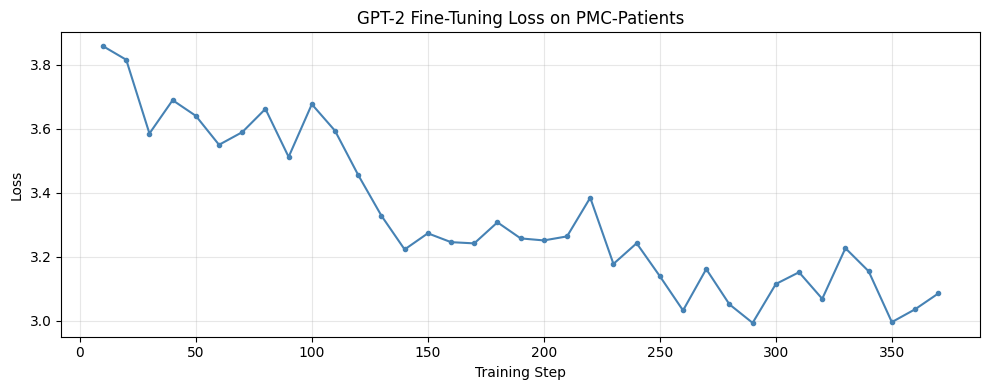

Final loss: 3.0849


In [13]:
# Extract training loss from Trainer's log history
train_losses = [entry['loss'] for entry in trainer.state.log_history if 'loss' in entry]
train_steps = [entry['step'] for entry in trainer.state.log_history if 'loss' in entry]

plt.figure(figsize=(10, 4))
plt.plot(train_steps, train_losses, marker='o', markersize=3, color='steelblue')
plt.xlabel('Training Step')
plt.ylabel('Loss')
plt.title('GPT-2 Fine-Tuning Loss on PMC-Patients')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Final loss: {train_losses[-1]:.4f}" if train_losses else "No loss recorded")

### Generate AFTER fine-tuning

The model has now seen real clinical case patterns. Compare to the pre-fine-tuning output above.

In [14]:
prompt = "A 58-year-old male presented with"
print("=== Fine-tuned GPT-2 ===")
print(generate_text(base_model, prompt))

=== Fine-tuned GPT-2 ===


A 58-year-old male presented with severe acute edema and right anterior pelvic floor pain for over 6 months and had a history of right dorsomandibular pain and dysarthria. The patient had been operated on by a local hospital for acute edema for 6 months and a bilateral edema lasting 2 months. The patient had been given an oral calcium-enriched calcium-cathal calcium (30 mg/day) by a local hospital for 4 months and was then treated with a calcium-enriched calcium-en


In [15]:
# Try a different prompt
prompt = "A 72-year-old female with"
print("=== Fine-tuned GPT-2 ===")
print(generate_text(base_model, prompt))

=== Fine-tuned GPT-2 ===


A 72-year-old female with an open-cell lung disease presented with systemic respiratory distress and bronchospasm and bronchitis. The patient presented with a bilateral bronchus and an increased pulmonary volume. On examination, she had a total lung mass of 0.4 × 101 cm in diameter. Her blood pressure was 78/60 mmHg and bronchial pressure was 70/60 mmHg. Her oxygen saturation was 30/36 mmHg and her CO2 level was 12.9%. Her serum


### Inducing Hallucinations

Now let's push the model outside its training distribution. The model will confidently generate plausible-looking but fabricated clinical details.

In [16]:
hallucination_prompts = [
    "A 12-year-old child presented with",
    "The patient had a history of liver transplant and",
    "A pregnant woman at 32 weeks presented with",
]

print("=== Hallucination examples ===\n")
for prompt in hallucination_prompts:
    print(f"Prompt: {prompt}")
    print(generate_text(base_model, prompt, max_new_tokens=80))
    print("\n" + "-" * 60 + "\n")

=== Hallucination examples ===

Prompt: A 12-year-old child presented with


A 12-year-old child presented with a chest CT of the left chest and a left chest CT of the right chest. The child had a bilateral chest radiograph, which was normal. The CT was performed without any further medical treatment. The CT was unremarkable and was not associated with any other medical problems. The child was discharged from the hospital and a chest radiograph was performed. The CT was unremarkable and was not associated with

------------------------------------------------------------

Prompt: The patient had a history of liver transplant and


The patient had a history of liver transplant and thyroid carcinoma in childhood. His family members were not aware of the case.
The patient underwent a routine biopsy of the liver and thyroid for a tumour. He was treated with a dose of 1,000 mg per kg body weight. He was referred to our hospital for further treatment. The patient was referred to our clinic due to a complication of the liver transplant. On the day of

------------------------------------------------------------

Prompt: A pregnant woman at 32 weeks presented with


A pregnant woman at 32 weeks presented with a persistent headache for several days. The patient's symptoms were similar to previous episodes of nausea, vomiting, and diarrhea. There was no history of a previous episode of this headache. The patient was diagnosed with a history of myeloid haemorrhoid haemorrhage with a history of abdominal cramps, vomiting, and diarrhea. Patient was admitted to the hospital, and a history

------------------------------------------------------------



The model generates confident, structured clinical text — but the specific values (lab results, vitals, doses) are fabricated. It learned the _style_ of case reports from fine-tuning, but it doesn't have real medical knowledge.

This is the hallucination problem from the lecture: the model extrapolates beyond its training data without knowing it's doing so. There is no general solution — only mitigations (RAG, output validation, human review).